In [7]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt

## Create Custom Mesh

In [8]:
EDGE_LENGTH = 0.01  # custom value
EDGE_OFFSET = 1e-3

RA = 0.3
DD = 0.01
HM = 0.08
BM = 0.08
MA = 0.01
MB = 0.05
RM0 = 0.095
ZM0 = 0.1
LLS = 0.001
SD = 0.005
SH = 0.01

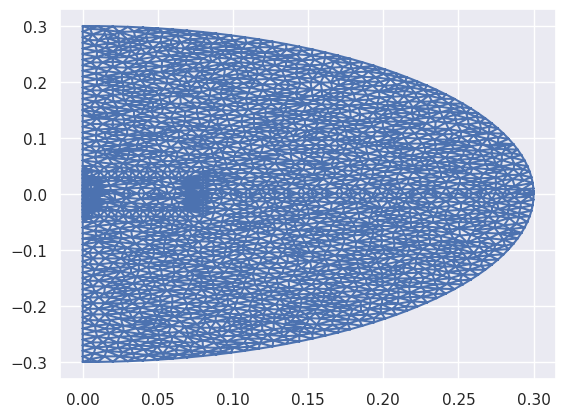

In [9]:

# Randkurve
knots1, elements1 = mt.CircleSegments([0,0], radius=RA, a_min=-np.pi/2, a_max=np.pi/2, edge_length=EDGE_LENGTH)
knots2, elements2 = mt.LineSegments([0, RA], [0, -RA], edge_length=EDGE_LENGTH)
knots, elements = mt.AddSegments(knots1, knots2, closed=True)
 
# R Achse
knots3, elements3 = mt.LineSegments([EDGE_OFFSET, EDGE_OFFSET], [RA, EDGE_OFFSET], edge_length=EDGE_LENGTH/2)
knots, elements = mt.AddCurves(knots, elements, knots3, elements3)

# Material
knots4, elements4 = mt.RectangleSegments([EDGE_OFFSET, -HM/2], [BM, HM/2], edge_length=EDGE_LENGTH/2)   # border
knots, elements = mt.AddCurves(knots, elements, knots4, elements4)

knots5, elements5 = mt.RectangleSegments([DD, -HM/2+DD], [BM-DD, HM/2-DD])  # inner border
knots, elements = mt.AddCurves(knots, elements, knots5, elements5)

# mt.PlotBoundary(knots, elements, "Curves")
# plt.show()
poi,tri,BouE,li_BE,bou_elem,CuE,li_CE = mt.DoTriMesh(knots, elements, edge_length=EDGE_LENGTH)

In [10]:
# Randkurven
Ps=[[0,RA],[0,-RA],[0,RA]]
bseg=mt.RetrieveSegments(knots,BouE,li_BE,Ps,['Nodes','Segments'])
mt.PlotBoundary(knots,bseg[0],'Nodes')
mt.PlotBoundary(knots,bseg[1],'Segments')
plt.show()

IndexError: index 335 is out of bounds for axis 0 with size 332